<a href="https://colab.research.google.com/github/SIVA-9550/MOBILENET-V3-SEA-FOOD-CLASSIFICATION-FINAL-MODEL/blob/main/MOBILENET_V3_SEA_FOOD_CLASSIFICATION_FINAL_MODEL.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import kagglehub
crowww_a_large_scale_fish_dataset_path = kagglehub.dataset_download('crowww/a-large-scale-fish-dataset')

print('Data source import complete.')


100%|██████████| 3.24G/3.24G [00:34<00:00, 99.5MB/s]

Extracting files...


Data source import complete.


In [ ]:
import os
print(os.listdir())

['.config', 'sample_data']


In [ ]:
print(os.listdir(crowww_a_large_scale_fish_dataset_path))

['NA_Fish_Dataset', 'license.txt', 'README.txt', 'Fish_Dataset', 'Segmentation_example_script.m']


In [ ]:
import os

DATA_DIR = os.path.join(
    crowww_a_large_scale_fish_dataset_path,
    "Fish_Dataset",
    "Fish_Dataset"
)

print("Classes:", os.listdir(DATA_DIR))

Classes: ['Trout', 'Striped Red Mullet', 'Sea Bass', 'Hourse Mackerel', 'Gilt-Head Bream', 'Black Sea Sprat', 'Shrimp', 'license.txt', 'Red Sea Bream', 'README.txt', 'Segmentation_example_script.m', 'Red Mullet']


In [ ]:
import os

BASE_PATH = crowww_a_large_scale_fish_dataset_path + "/Fish_Dataset/Fish_Dataset"

old_name = os.path.join(BASE_PATH, "Hourse Mackerel")
new_name = os.path.join(BASE_PATH, "Horse Mackerel")

os.rename(old_name, new_name)

print("✅ Renamed successfully!")
print("Updated Classes:", os.listdir(BASE_PATH))

✅ Renamed successfully!
Updated Classes: ['Trout', 'Striped Red Mullet', 'Sea Bass', 'Horse Mackerel', 'Gilt-Head Bream', 'Black Sea Sprat', 'Shrimp', 'license.txt', 'Red Sea Bream', 'README.txt', 'Segmentation_example_script.m', 'Red Mullet']


In [ ]:
DATA_DIR = crowww_a_large_scale_fish_dataset_path + "/Fish_Dataset/Fish_Dataset"

In [ ]:
import tensorflow as tf

In [ ]:
import tensorflow as tf
import os
DATA_DIR = crowww_a_large_scale_fish_dataset_path + "/Fish_Dataset/Fish_Dataset"
train_ds = tf.keras.utils.image_dataset_from_directory(
    DATA_DIR,
    validation_split=0.2,
    subset="training",
    seed=123,
    image_size=(224,224),
    batch_size=32
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    DATA_DIR,
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=(224,224),
    batch_size=32
)

print("Classes:", train_ds.class_names)

Found 18000 files belonging to 9 classes.
Using 14400 files for training.
Found 18000 files belonging to 9 classes.
Using 3600 files for validation.
Classes: ['Black Sea Sprat', 'Gilt-Head Bream', 'Horse Mackerel', 'Red Mullet', 'Red Sea Bream', 'Sea Bass', 'Shrimp', 'Striped Red Mullet', 'Trout']


In [ ]:
import os, shutil

SRC = os.path.join(crowww_a_large_scale_fish_dataset_path, "Fish_Dataset", "Fish_Dataset")
CLEAN = "/content/Fish9"

os.makedirs(CLEAN, exist_ok=True)
classes = [d for d in os.listdir(SRC) if os.path.isdir(os.path.join(SRC, d))]
print("Original classes:", classes)

copied = 0
for cls in classes:
    src_cls = os.path.join(SRC, cls)
    inner = os.path.join(src_cls, cls)
    if not os.path.exists(inner):
        subs = [s for s in os.listdir(src_cls) if os.path.isdir(os.path.join(src_cls, s)) and "GT" not in s]
        if len(subs) == 0:
            print("Skipping (no inner non-GT folder):", cls)
            continue
        inner = os.path.join(src_cls, subs[0])
    out_name = "Horse Mackerel" if cls.strip() == "Hourse Mackerel" else cls
    out_cls = os.path.join(CLEAN, out_name)
    os.makedirs(out_cls, exist_ok=True)

    for fn in os.listdir(inner):
        if fn.lower().endswith((".jpg", ".jpeg", ".png")):
            shutil.copy2(os.path.join(inner, fn), os.path.join(out_cls, fn))
            copied += 1

print("✅ Clean dataset created at:", CLEAN)
print("✅ Total images copied:", copied)
print("✅ Clean classes:", sorted(os.listdir(CLEAN)))

Original classes: ['Trout', 'Striped Red Mullet', 'Sea Bass', 'Horse Mackerel', 'Gilt-Head Bream', 'Black Sea Sprat', 'Shrimp', 'Red Sea Bream', 'Red Mullet']
✅ Clean dataset created at: /content/Fish9
✅ Total images copied: 9000
✅ Clean classes: ['Black Sea Sprat', 'Gilt-Head Bream', 'Horse Mackerel', 'Red Mullet', 'Red Sea Bream', 'Sea Bass', 'Shrimp', 'Striped Red Mullet', 'Trout']


In [ ]:
import tensorflow as tf

DATA_DIR = "/content/Fish9"

train_ds = tf.keras.utils.image_dataset_from_directory(
    DATA_DIR,
    validation_split=0.2,
    subset="training",
    seed=123,
    image_size=(224,224),
    batch_size=32
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    DATA_DIR,
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=(224,224),
    batch_size=32
)

print("✅ Classes:", train_ds.class_names)

Found 9000 files belonging to 9 classes.
Using 7200 files for training.
Found 9000 files belonging to 9 classes.
Using 1800 files for validation.
✅ Classes: ['Black Sea Sprat', 'Gilt-Head Bream', 'Horse Mackerel', 'Red Mullet', 'Red Sea Bream', 'Sea Bass', 'Shrimp', 'Striped Red Mullet', 'Trout']


In [ ]:
import tensorflow as tf
from tensorflow.keras import layers

IMG_SIZE = 224
BATCH = 32
NUM_CLASSES = 9

AUTOTUNE = tf.data.AUTOTUNE
train_ds2 = train_ds.shuffle(1000).prefetch(AUTOTUNE)
val_ds2 = val_ds.prefetch(AUTOTUNE)

base = tf.keras.applications.MobileNetV3Small(
    input_shape=(IMG_SIZE, IMG_SIZE, 3),
    include_top=False,
    weights="imagenet"
)
base.trainable = False

inputs = tf.keras.Input(shape=(IMG_SIZE, IMG_SIZE, 3), name="image")
x = tf.keras.applications.mobilenet_v3.preprocess_input(inputs)
x = layers.RandomFlip("horizontal")(x)
x = layers.RandomRotation(0.05)(x)
x = layers.RandomZoom(0.10)(x)

x = base(x, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.25)(x)
outputs = layers.Dense(NUM_CLASSES, activation="softmax")(x)

model = tf.keras.Model(inputs, outputs)

model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

callbacks = [
    tf.keras.callbacks.ModelCheckpoint("best.keras", save_best_only=True, monitor="val_accuracy", mode="max"),
    tf.keras.callbacks.EarlyStopping(patience=5, restore_best_weights=True, monitor="val_accuracy"),
    tf.keras.callbacks.ReduceLROnPlateau(patience=2, factor=0.5, monitor="val_loss"),
]

history = model.fit(train_ds2, validation_data=val_ds2, epochs=15, callbacks=callbacks)

4334752/4334752 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/15
225/225 ━━━━━━━━━━━━━━━━━━━━ 78s 87ms/step - accuracy: 0.5215 - loss: 1.4104 - val_accuracy: 0.9689 - val_loss: 0.2624 - learning_rate: 0.0010
Epoch 2/15


In [ ]:
class_names = ['Black Sea Sprat', 'Gilt-Head Bream', 'Horse Mackerel', 'Red Mullet',
               'Red Sea Bream', 'Sea Bass', 'Shrimp', 'Striped Red Mullet', 'Trout']

with open("labels.txt", "w", encoding="utf-8") as f:
    for n in class_names:
        f.write(n + "\n")
print("✅ Saved labels.txt")

best_model = tf.keras.models.load_model("best.keras")

converter = tf.lite.TFLiteConverter.from_keras_model(best_model)
converter.optimizations = [tf.lite.Optimize.DEFAULT]
tflite_model = converter.convert()

with open("fish_model.tflite", "wb") as f:
    f.write(tflite_model)

print("✅ Saved fish_model.tflite MB:", len(tflite_model)/1024/1024)

✅ Saved labels.txt
Saved artifact at '/tmp/tmp6ynec2zl'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name='image')
Output Type:
  TensorSpec(shape=(None, 9), dtype=tf.float32, name=None)
Captures:
  139564561272656: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139564561277648: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139564561269200: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139564561269968: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139564561269008: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139564561281872: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139564561279184: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139564561281296: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139564561279952: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139564561271696: TensorSpec(shape=(), dtype=tf.resource, name=None)
  13

**MODEL CHECKING 1**

In [ ]:
from google.colab import files
uploaded = files.upload()  # choose 1 image from your dataset

Saving 01.png to 01.png


In [ ]:
import tensorflow as tf
import numpy as np

# Load trained Keras model
model = tf.keras.models.load_model("best.keras")

# Load labels
with open("labels.txt", "r", encoding="utf-8") as f:
    class_names = [line.strip() for line in f.readlines()]

print("Labels:", class_names)

Labels: ['Black Sea Sprat', 'Gilt-Head Bream', 'Horse Mackerel', 'Red Mullet', 'Red Sea Bream', 'Sea Bass', 'Shrimp', 'Striped Red Mullet', 'Trout']


In [ ]:
import os
from tensorflow.keras.utils import load_img, img_to_array

# Get uploaded file name
img_path = "/content/" + list(uploaded.keys())[0]
print("Testing image:", img_path)

img = load_img(img_path, target_size=(224,224))
x = img_to_array(img)          # 0..255
x = np.expand_dims(x, axis=0)  # (1,224,224,3)

probs = model.predict(x, verbose=0)[0]
top3 = np.argsort(probs)[::-1][:3]

print("\nTOP-3 Predictions:")
for i in top3:
    print(f"{class_names[int(i)]}  ->  {float(probs[int(i)]):.6f}")

Testing image: /content/01.png

TOP-3 Predictions:
Shrimp  ->  0.999391
Striped Red Mullet  ->  0.000559
Horse Mackerel  ->  0.000039


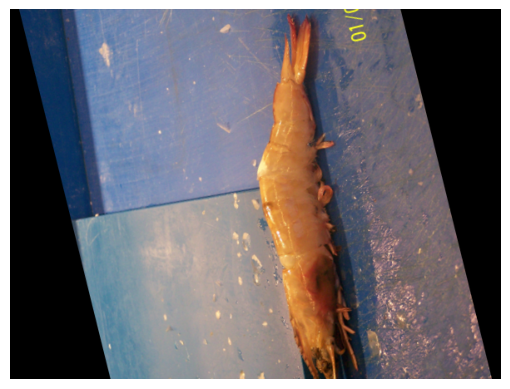

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

img_show = mpimg.imread(img_path)
plt.figure()
plt.imshow(img_show)
plt.axis("off")
plt.show()

**MODEL CHECKING 2**

In [ ]:
from google.colab import files
uploaded = files.upload()  # choose 1 image from your dataset

Saving 02.png to 02.png


In [ ]:
import os
from tensorflow.keras.utils import load_img, img_to_array

# Get uploaded file name
img_path = "/content/" + list(uploaded.keys())[0]
print("Testing image:", img_path)

img = load_img(img_path, target_size=(224,224))
x = img_to_array(img)          # 0..255
x = np.expand_dims(x, axis=0)  # (1,224,224,3)

probs = model.predict(x, verbose=0)[0]
top3 = np.argsort(probs)[::-1][:3]

print("\nTOP-3 Predictions:")
for i in top3:
    print(f"{class_names[int(i)]}  ->  {float(probs[int(i)]):.6f}")

Testing image: /content/02.png

TOP-3 Predictions:
Red Mullet  ->  0.999999
Striped Red Mullet  ->  0.000001
Shrimp  ->  0.000000


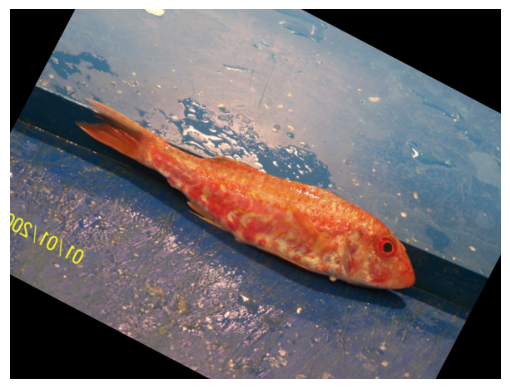

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

img_show = mpimg.imread(img_path)
plt.figure()
plt.imshow(img_show)
plt.axis("off")
plt.show()

**MODEL CHECKING 3**

In [ ]:
from google.colab import files
uploaded = files.upload()  # choose 1 image from your dataset

Saving 6.png to 6.png


In [ ]:
import os
from tensorflow.keras.utils import load_img, img_to_array

# Get uploaded file name
img_path = "/content/" + list(uploaded.keys())[0]
print("Testing image:", img_path)

img = load_img(img_path, target_size=(224,224))
x = img_to_array(img)          # 0..255
x = np.expand_dims(x, axis=0)  # (1,224,224,3)

probs = model.predict(x, verbose=0)[0]
top3 = np.argsort(probs)[::-1][:3]

print("\nTOP-3 Predictions:")
for i in top3:
    print(f"{class_names[int(i)]}  ->  {float(probs[int(i)]):.6f}")

Testing image: /content/6.png

TOP-3 Predictions:
Trout  ->  0.998208
Gilt-Head Bream  ->  0.001224
Sea Bass  ->  0.000567


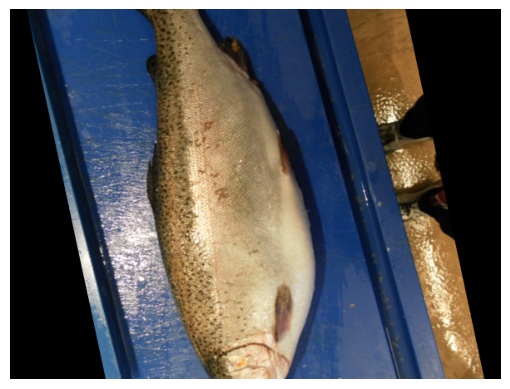

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

img_show = mpimg.imread(img_path)
plt.figure()
plt.imshow(img_show)
plt.axis("off")
plt.show()